<a href="https://colab.research.google.com/github/d-monkey-CG/DFW-Residential-Housing-Price-Predictor/blob/main/DFW_Home_Price_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exploratory Data Analysis of the (preliminary) completed DFW Home Price Dataset**

Note: Only the three most populous and/or fastest growing counties were included in this dataset (Dallas County, Tarrant County, Collin County). The data available for all three is from 2021 - 2025.

In [ ]:
#To import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#To load the dataset from google drive
data = pd.read_parquet('/content/drive/MyDrive/Python Data Science Honors Project/DFW_CBINC.parquet')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508395 entries, 0 to 11508394
Data columns (total 13 columns):
 #   Column                Dtype  
---  ------                -----  
 0   TaxYear               int64  
 1   YearBuilt             int64  
 2   ActualArea            int64  
 3   LandValue             int64  
 4   has_pool              bool   
 5   IndicatedEquityValue  int64  
 6   situsbldgnum          float64
 7   situsstreetprefix     object 
 8   situsstreetsuffix     object 
 9   situsstreetname       object 
 10  situszip              int64  
 11  county                object 
 12  Median_H_Inc          float64
dtypes: bool(1), float64(2), int64(6), object(4)
memory usage: 1.0+ GB


In [ ]:
#To drop rows where the property is most likely a mobile home
#Mobile homes are appraised differently B/C they are depreciating assets

data = data[~((data['LandValue'] == 0) & (data['IndicatedEquityValue'] < 50_000))]

#Convert 'has_pool' column from a bool data type to an int data type (0 or 1)

data['has_pool'] = data['has_pool'].astype(int)

In [ ]:
#Function To create a visual for each year where all counties have available data
#This visualization is meant to be easy to understand not STATS heavy

def lp_eda(year, data_load):
    df = data_load[data_load['TaxYear'] == year]

    #To create a visualization for the distibution of home appraisal values by year
    bins = [0, 200_000, 300_000, 400_000, 500_000, 750_000, 1_500_000, np.inf]
    labels = [
        "Under $200k",
        "$200k–$300k",
        "$300k–$400k",
        "$400k–$500k",
        "$500k–$750k",
        "$750k-$1.5M",
        "$1.5M+"
    ]

    price_groups = pd.cut(df["IndicatedEquityValue"],
                          bins=bins,
                          labels=labels,
                          include_lowest=True
                          )
    counts = price_groups.value_counts().reindex(labels)

    plt.figure(figsize=(6, 6))
    plt.bar(counts.index, counts.values, color='skyblue')
    plt.title(f"Home Appraisal Value Distribution - {year}")
    plt.xlabel("Appraisal Value Range")
    plt.ylabel("Number of Homes")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


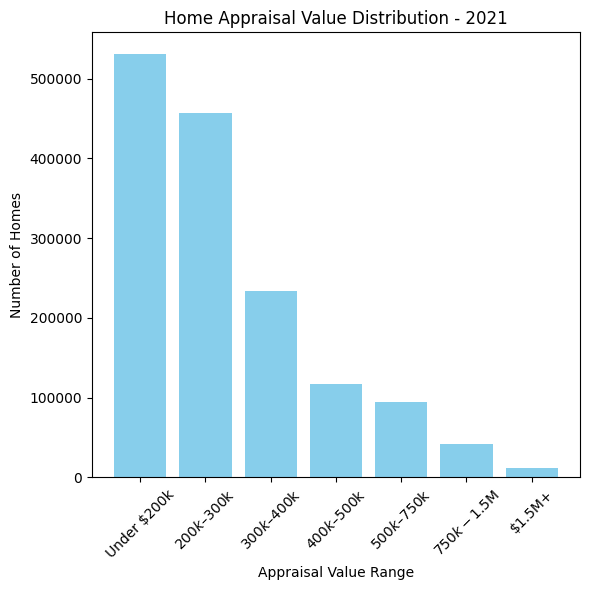

In [ ]:
lp_eda(2021, data)

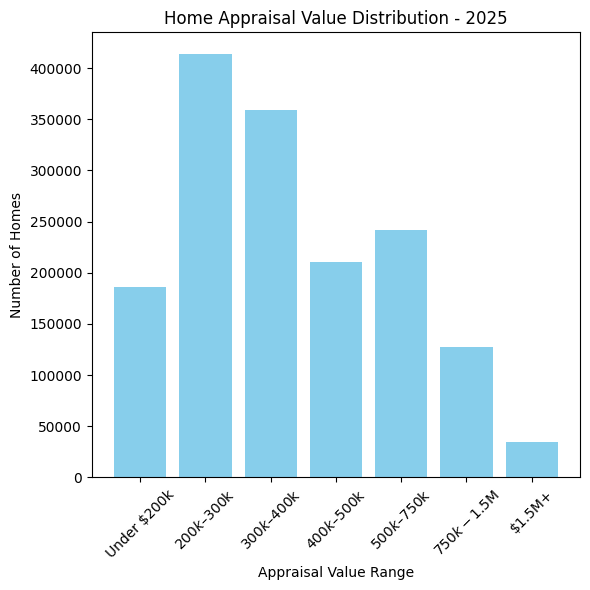

In [ ]:
lp_eda(2025, data)

In [ ]:
#To create dataframes for 2021 and 2025 to see the Appraisal changes over a 5 yr period
#This portion is more STATS oriented

df_2021 = data[data['TaxYear'] == 2021]
val_2021 = df_2021['IndicatedEquityValue']

df_2025 = data[data['TaxYear'] == 2025]
val_2025 = df_2025['IndicatedEquityValue']

In [ ]:
#To calulcate the skewness and curtosis of residential home values
#We should expect to see a really high number for skewness as home values tend
#to have a long right tail

from scipy.stats import skew, kurtosis

shape_stats_21 = {
    "skewness": skew(val_2021),
    "kurtosis": kurtosis(val_2021),
}

print('FY 2021')
pd.Series(shape_stats_21)

FY 2021


,0
skewness,20.965922
kurtosis,1634.336108


In [ ]:
shape_stats_25 = {
    "skewness": skew(val_2025),
    "kurtosis": kurtosis(val_2025),
}

print('FY 2025')
pd.Series(shape_stats_25)

FY 2025


,0
skewness,15.001660
kurtosis,643.623623


Based on these results we can conclude that the **average** home appraisal value is not a useful metric because the skewness and kurtosis are extremely high, the **median** value is going to be the more accurate metric.

However, it is important to note that both skewness and kurtosis decreased significantly over the 5 year period.

Another important finding is that the 2021 visualization looks nothing like a typical bell curve, but the shape of the 2025 visual does have a more normal bell curve shape.

In theory this is a good thing as it results in a better distribution, but in practice it means that there are significantly less homes that are valued at under 300K and significantly more homes in the 400K to 750K range.

These figures don't represent exact numbers, but are in fact good estimates for the area.

In [ ]:
val_2021.median()

240720.0

In [ ]:
val_2025.median()

345475.0

In [ ]:
#To calculate the %change in aggregate median appraisal values from 2021 - 2025

change_per = val_2025.median() / val_2021.median()

print(f"The median home appraisal value difference from 2021 - 2025 is {change_per - 1}")

The median home appraisal value difference from 2021 - 2025 is 0.43517364572947814


Next we will slice the dataset by zipcode, I want to make sure that the overall trends we see in the appraisal values are true in individual zipcodes as well.

I am checking for **Simpson's Paradox** so I will slice the data several different ways below and make the calculations for the total datset and individual slices.

The best way to do this due to the size and scope of the dataset is to use a table format and filter for any negative median price changes over the period of 2021-2025.

In [ ]:
ZIP_COL  = "situszip"
YEAR_COL = "TaxYear"
VAL_COL  = "IndicatedEquityValue"

data = data.copy()
data[ZIP_COL] = data[ZIP_COL].astype(str).str.zfill(5)
data = data.dropna(subset=[ZIP_COL, YEAR_COL, VAL_COL])

data = data[data[YEAR_COL].between(2021, 2025)]

#ZIP-level trend (median per year)
zip_by_year = (
    data.groupby([ZIP_COL, YEAR_COL])[VAL_COL]
      .median()
      .reset_index(name="zip_median")
      .sort_values([ZIP_COL, YEAR_COL])
)


In [ ]:
zip_by_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1179 entries, 0 to 1178
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   situszip    1179 non-null   object 
 1   TaxYear     1179 non-null   int64  
 2   zip_median  1179 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 27.8+ KB


In [ ]:
#To pivot the TaxYear values from rows to columns
zip_by_yr = zip_by_year.pivot(index="situszip",
                  columns="TaxYear",
                  values="zip_median").reset_index()

zip_by_yr['Total_%_Change'] = (zip_by_yr[2025] / zip_by_yr[2021]) - 1

zip_by_yr = zip_by_yr.reset_index(drop=True)

#To format the metadata
zip_by_yr.columns.name = None

zip_by_yr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   situszip        237 non-null    object 
 1   2021            235 non-null    float64
 2   2022            235 non-null    float64
 3   2023            236 non-null    float64
 4   2024            236 non-null    float64
 5   2025            237 non-null    float64
 6   Total_%_Change  235 non-null    float64
dtypes: float64(6), object(1)
memory usage: 13.1+ KB


In [ ]:
zip_by_yr.head()

,situszip,2021,2022,2023,2024,2025,Total_%_Change
0,75001,343510.0,377415.0,422590.0,488000.0,497800.0,0.449157
1,75002,313625.5,406609.0,465836.0,475422.0,470625.0,0.500595
2,75006,233370.0,276160.0,306030.0,339030.0,342630.0,0.468184
3,75007,230260.0,267990.0,308995.0,329940.0,349920.0,0.519673
4,75009,334410.0,458133.0,524074.0,550035.0,541068.0,0.617978


In [ ]:
#To filter for any negative values in the %_change column

zip_negative = zip_by_yr['Total_%_Change'] <= 0

zip_negative.value_counts()

,count
Total_%_Change,
False,237


Based on the calculations above we can see that there are no negative values in the column that calculates the 5 year % appraisal value change for any of our zipcodes. This is good, it means that the overall direction of the aggregate dataset is not in conflict with any individual data slice.

In [ ]:
zip_by_yr.nlargest(10, 'Total_%_Change')

,situszip,2021,2022,2023,2024,2025,Total_%_Change
54,75125,37200.0,60020.0,61590.0,71010.0,94000.0,1.526882
84,75215,67510.0,104000.0,125890.0,152250.0,160510.0,1.377574
80,75210,61575.0,84090.0,114480.0,136320.0,139500.0,1.265530
65,75172,109640.0,159120.0,173150.0,214590.0,225460.0,1.056366
73,75203,112320.0,166840.0,181925.0,218280.0,227620.0,1.026531
125,75491,225295.0,283875.0,291562.0,492731.0,443036.0,0.966471
82,75212,137880.0,191000.0,215400.0,259945.0,270010.0,0.958297
85,75216,105040.0,142060.0,157880.0,193585.0,198360.0,0.888423
57,75141,136530.0,155860.0,239300.0,252760.0,255040.0,0.868014
216,76164,102804.0,115619.0,182979.0,191513.0,191301.0,0.860832


In [ ]:
zip_by_yr.nsmallest(10, 'Total_%_Change')

,situszip,2021,2022,2023,2024,2025,Total_%_Change
7,75022,783925.0,803021.0,1001779.0,864306.0,810407.5,0.033782
49,75097,164607.0,173859.5,201103.5,205436.0,178481.0,0.084286
178,76102,272526.0,270682.0,307813.5,316485.0,302366.0,0.109494
111,75247,76600.0,76600.0,76600.0,89150.0,89150.0,0.163838
72,75202,250800.0,274250.0,274250.0,302800.0,302800.0,0.207337
71,75201,828480.0,842450.0,865060.0,975000.0,1004240.0,0.212148
166,76066,360719.0,414741.0,455364.0,442485.0,441560.0,0.224111
167,76071,425491.0,552433.0,567136.0,561824.0,533756.0,0.254447
215,76163,300315.0,332090.0,398887.0,378935.5,379321.5,0.263079
147,76024,365962.5,364673.5,493464.0,468587.5,468180.0,0.279311


Based on the tables above we can see that the largest % gains are occurring in zipcodes where the starting median appraisal values in 2021 were very, very low relative to the aggregate median value.

This definitely points to a potential affordability problem.

Next we will calculate the correlation scores and create the correlation matrix to help us visualize the relationships between different features (columns).

In [ ]:
#To create a new df that excludes non-numeric columns

numeric_data = data[['TaxYear',
                    'YearBuilt',
                    'ActualArea',
                    'LandValue',
                    'has_pool',
                    'IndicatedEquityValue',
                    'Median_H_Inc']]

#To calculate the correlation scores for the overall dataset before slicing
matrix = numeric_data.corr().round(2)

#To create the visualization for the correlation matrix
matrix.style.background_gradient()

,TaxYear,YearBuilt,ActualArea,LandValue,has_pool,IndicatedEquityValue,Median_H_Inc
TaxYear,1.000000,0.010000,0.010000,0.080000,0.000000,0.130000,0.170000
YearBuilt,0.010000,1.000000,0.130000,0.010000,0.040000,0.090000,0.140000
ActualArea,0.010000,0.130000,1.000000,0.340000,0.280000,0.510000,0.280000
LandValue,0.080000,0.010000,0.340000,1.000000,0.200000,0.810000,0.210000
has_pool,0.000000,0.040000,0.280000,0.200000,1.000000,0.330000,0.210000
IndicatedEquityValue,0.130000,0.090000,0.510000,0.810000,0.330000,1.000000,0.330000
Median_H_Inc,0.170000,0.140000,0.280000,0.210000,0.210000,0.330000,1.000000


Based on the table above we see that the best predictors of appraised home value are the land value and the square footage of the property. I find it interesting that median household income doesn't have a stronger correlation (0.33) to appraised value. There is also a strong possibility that land value is a proxy for zipcode.

In [61]:
#To select individual zipcodes for further drilldown

zip_code = '75203'

zip_individual = zip_by_yr[zip_by_yr['situszip'] == zip_code]

zip_individual.head()

,situszip,2021,2022,2023,2024,2025,Total_%_Change
73,75203,112320.0,166840.0,181925.0,218280.0,227620.0,1.026531


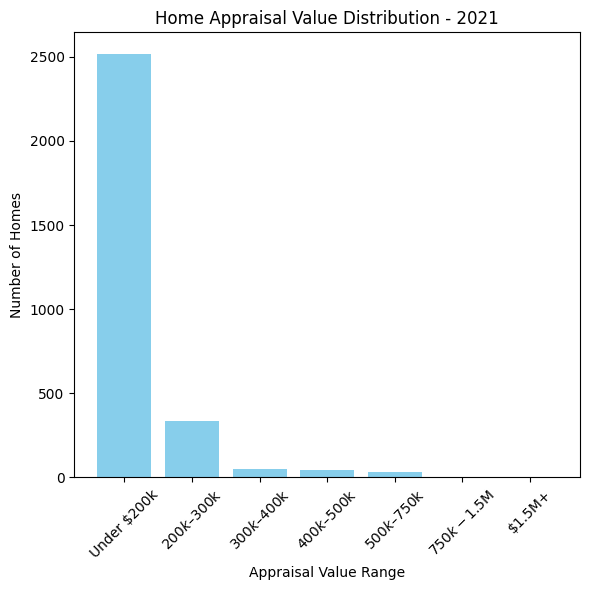

In [62]:
data_drilldown = data[data['situszip'] == zip_code]

lp_eda(2021, data_drilldown)

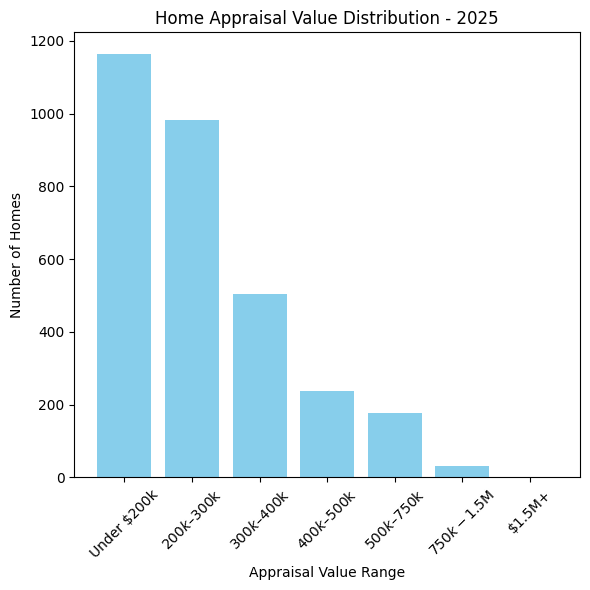

In [63]:
lp_eda(2025, data_drilldown)